# Explotary Data Analysis for New Egg Products

In [2]:
# Load dataset and view basic structure
import pandas as pd
import numpy as np

pd.set_option("display.max_rows", None)
pd.set_option("display.max_seq_items", None)

new_egg_df=pd.read_csv("filtered_products_newegg.csv")



## Data Inspection and Cleaning

This section examines the structure and quality of the dataset to ensure it is prepared for analysis. The number of rows and columns, data types and missing values are inspected. These checks help identify incomplete, duplicated, or inconsistent records. Rows with missing values are removed, duplicate entries are dropped, and products with zero reviews are filtered out, as they do not contribute meaningful insight. A final structural check confirms that the dataset is complete, consistent, and ready for exploratory analysis

In [3]:
#shape
new_egg_df.shape

(2605, 10)

In [4]:
# Check structure
new_egg_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2605 entries, 0 to 2604
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   itemNumber             2605 non-null   object 
 1   class                  2605 non-null   object 
 2   name                   2603 non-null   object 
 3   customerReviewAverage  2605 non-null   float64
 4   customerReviewCount    2605 non-null   int64  
 5   customerTopRated       2605 non-null   bool   
 6   modelNumber            2602 non-null   object 
 7   salePrice              2605 non-null   float64
 8   manufacturer           2605 non-null   object 
 9   isRefurbished          2605 non-null   bool   
dtypes: bool(2), float64(2), int64(1), object(5)
memory usage: 168.0+ KB


In [5]:
# Missing values summary
new_egg_df.isnull().sum()

itemNumber               0
class                    0
name                     2
customerReviewAverage    0
customerReviewCount      0
customerTopRated         0
modelNumber              3
salePrice                0
manufacturer             0
isRefurbished            0
dtype: int64

In [6]:
# Print the number of rows and columns
print(f"The number of rows= {new_egg_df.shape[0]}")
print(f"The number of columns= {new_egg_df.shape[1]}")

The number of rows= 2605
The number of columns= 10


In [7]:
#display the columns
new_egg_df.columns

Index(['itemNumber', 'class', 'name', 'customerReviewAverage',
       'customerReviewCount', 'customerTopRated', 'modelNumber', 'salePrice',
       'manufacturer', 'isRefurbished'],
      dtype='object')

In [8]:
new_egg_df.columns.to_list()

['itemNumber',
 'class',
 'name',
 'customerReviewAverage',
 'customerReviewCount',
 'customerTopRated',
 'modelNumber',
 'salePrice',
 'manufacturer',
 'isRefurbished']

In [9]:
# Data Types
new_egg_df.dtypes

itemNumber                object
class                     object
name                      object
customerReviewAverage    float64
customerReviewCount        int64
customerTopRated            bool
modelNumber               object
salePrice                float64
manufacturer              object
isRefurbished               bool
dtype: object

In [10]:
#remove rows that are empty
new_egg_df = new_egg_df.dropna()

In [11]:
# Drop duplicates if any
new_egg_df.drop_duplicates(inplace=True)

In [12]:
new_egg_df.isnull().sum()

itemNumber               0
class                    0
name                     0
customerReviewAverage    0
customerReviewCount      0
customerTopRated         0
modelNumber              0
salePrice                0
manufacturer             0
isRefurbished            0
dtype: int64

In [13]:
new_egg_df = new_egg_df[new_egg_df['customerReviewCount'] != 0]

In [14]:
new_egg_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 618 entries, 0 to 2587
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   itemNumber             618 non-null    object 
 1   class                  618 non-null    object 
 2   name                   618 non-null    object 
 3   customerReviewAverage  618 non-null    float64
 4   customerReviewCount    618 non-null    int64  
 5   customerTopRated       618 non-null    bool   
 6   modelNumber            618 non-null    object 
 7   salePrice              618 non-null    float64
 8   manufacturer           618 non-null    object 
 9   isRefurbished          618 non-null    bool   
dtypes: bool(2), float64(2), int64(1), object(5)
memory usage: 44.7+ KB


## Descriptive Statistics

This section provides an initial exploration of the dataset to understand patterns, distributions, and key characteristics. Numerical features are summarized using measures such as mean, median, quartiles, and standard deviation, while categorical variables are described through frequency counts. These outputs reveal how ratings, review counts, and prices are distributed, and how product categories and manufacturers are represented. The results help identify early trends in customer behavior, product performance, and dataset composition.

In [15]:
# Summary statistics for numeric columns
new_egg_df.describe()
new_egg_df.describe(percentiles=[.1, .25, .5, .75, .9])

,customerReviewAverage,customerReviewCount,salePrice
count,618.000000,618.000000,618.000000
mean,4.214725,31.804207,954.188091
std,1.031871,93.610588,883.862430
min,1.000000,1.000000,79.000000
10%,3.000000,1.000000,178.466000
25%,4.000000,1.000000,318.240000
50%,4.500000,3.000000,671.000000
75%,5.000000,20.750000,1379.990000
90%,5.000000,71.000000,1999.990000
max,5.000000,892.000000,7499.000000


In [16]:
# Summary statistics for categorical columns
new_egg_df.describe(include='object')

,itemNumber,class,name,modelNumber,manufacturer
count,618,618,618,618,618
unique,618,3,615,607,70
top,83-360-831,desktop,HP EliteDesk 800 G9 Mini Desktop Intel Core i7...,FX608JHR-ES73,DELL
freq,1,423,2,4,92


In [17]:
# Univariate Analysis — Numerical
print('Review count Summary:\n ', new_egg_df['customerReviewCount'].describe())
print('\nReview avg Score Summary:\n ', new_egg_df['customerReviewAverage'].describe())
print('\n Sale Price Summary:\n ', new_egg_df['salePrice'].describe())

# Univariate Analysis — Categorical
print('\nManufacturer Summary:\n ', new_egg_df['manufacturer'].describe())
print('\nclass Summary:\n ', new_egg_df['class'].describe())
print('\nModel number Summary:\n ', new_egg_df['modelNumber'].describe())
print('\ncondition Summary:\n ', new_egg_df['isRefurbished'].describe())

# Value counts help us understand category frequency distribution.
print('\nManufacturer num:\n ', new_egg_df['manufacturer'].value_counts())
print('\nclass num:\n ', new_egg_df['class'].value_counts())

Review count Summary:
  count    618.000000
mean      31.804207
std       93.610588
min        1.000000
25%        1.000000
50%        3.000000
75%       20.750000
max      892.000000
Name: customerReviewCount, dtype: float64

Review avg Score Summary:
  count    618.000000
mean       4.214725
std        1.031871
min        1.000000
25%        4.000000
50%        4.500000
75%        5.000000
max        5.000000
Name: customerReviewAverage, dtype: float64

 Sale Price Summary:
  count     618.000000
mean      954.188091
std       883.862430
min        79.000000
25%       318.240000
50%       671.000000
75%      1379.990000
max      7499.000000
Name: salePrice, dtype: float64

Manufacturer Summary:
  count      618
unique      70
top       DELL
freq        92
Name: manufacturer, dtype: object

class Summary:
  count         618
unique          3
top       desktop
freq          423
Name: class, dtype: object

Model number Summary:
  count               618
unique              607
top     

## Detailed Statistical Summaries & Outlier Analysis

This section computes central tendency and variability measures for key numerical variables, including review count, review rating, and sale price. Statistics such as mean, median, mode, variance, and standard deviation describe typical values and the spread of the data. Outlier detection is performed using both the Interquartile Range (IQR) method and z-scores to identify unusually high or low observations. These outliers are important to recognize because they may influence averages or indicate exceptional product cases.

In [18]:

# Numerical summaries
print("Review Count")
print("Mean Review Count:", new_egg_df['customerReviewCount'].mean())
print("Median Review Count:", new_egg_df['customerReviewCount'].median())
print("Mode Review Count:", new_egg_df['customerReviewCount'].mode()[0])
print("Std of Review Count:",new_egg_df['customerReviewCount'].std() )
print("Variance of Review Count:",new_egg_df['customerReviewCount'].var() )
print("Min & Max Review Count:",new_egg_df['customerReviewCount'].min(), new_egg_df['customerReviewCount'].max() )

# Using IQR (inter quartile range) method
Q1 = new_egg_df['customerReviewCount'].quantile(.25)
Q3 = new_egg_df['customerReviewCount'].quantile(.75)
IQR = Q3 - Q1

lower_fence = Q1 - IQR*1.5
upper_fence = Q3 + IQR*1.5
outliers = new_egg_df[(new_egg_df['customerReviewCount']<lower_fence)|(new_egg_df['customerReviewCount']>upper_fence)]
print("Number of outliers Review Count:", outliers.shape[0])

# Using Z-Score method
from scipy import stats
z = stats.zscore(new_egg_df['customerReviewCount'])
print("Potential outliers (Z > 3):", new_egg_df[abs(z) > 3].shape[0])

print("\nReview Rating")
print("Mean Review Rating:", new_egg_df['customerReviewAverage'].mean())
print("Median Review Rating:", new_egg_df['customerReviewAverage'].median())
print("Mode Review Rating:", new_egg_df['customerReviewAverage'].mode()[0])
print("Std of Review Rating:",new_egg_df['customerReviewAverage'].std() )
print("Variance of Review Rating:",new_egg_df['customerReviewAverage'].var() )
print("Min & Max Review Rating:",new_egg_df['customerReviewAverage'].min(), new_egg_df['customerReviewAverage'].max() )

# Using IQR (inter quartile range) method
Q1 = new_egg_df['customerReviewAverage'].quantile(.25)
Q3 = new_egg_df['customerReviewAverage'].quantile(.75)
IQR = Q3 - Q1

lower_fence = Q1 - IQR*1.5
upper_fence = Q3 + IQR*1.5
outliers = new_egg_df[(new_egg_df['customerReviewAverage']<lower_fence)|(new_egg_df['customerReviewAverage']>upper_fence)]
print("Number of outliers Review Rating:", outliers.shape[0])

# Using Z-Score method
z = stats.zscore(new_egg_df['customerReviewAverage'])
print("Potential outliers (Z > 3):", new_egg_df[abs(z) > 3].shape[0])

print("\nSale Price")
print("Mean Sale Price:", new_egg_df['salePrice'].mean())
print("Median Sale Price:", new_egg_df['salePrice'].median())
print("Mode Sale Price:", new_egg_df['salePrice'].mode()[0])
print("Std of Sale Price:",new_egg_df['salePrice'].std() )
print("Variance of Sale Price:",new_egg_df['salePrice'].var() )
print("Min & Max Sale Price:",new_egg_df['salePrice'].min(), new_egg_df['salePrice'].max() )

# Using IQR (inter quartile range) method
Q1 = new_egg_df['salePrice'].quantile(.25)
Q3 = new_egg_df['salePrice'].quantile(.75)
IQR = Q3 - Q1

lower_fence = Q1 - IQR*1.5
upper_fence = Q3 + IQR*1.5
outliers = new_egg_df[(new_egg_df['salePrice']<lower_fence)|(new_egg_df['salePrice']>upper_fence)]
print("Number of outliers Sale Price:", outliers.shape[0])

# Using Z-Score method
z = stats.zscore(new_egg_df['salePrice'])
print("Potential outliers (Z > 3):", new_egg_df[abs(z) > 3].shape[0])



Review Count
Mean Review Count: 31.8042071197411
Median Review Count: 3.0
Mode Review Count: 1
Std of Review Count: 93.6105878310278
Variance of Review Count: 8762.94215407057
Min & Max Review Count: 1 892
Number of outliers Review Count: 97
Potential outliers (Z > 3): 13

Review Rating
Mean Review Rating: 4.214724919093851
Median Review Rating: 4.5
Mode Review Rating: 5.0
Std of Review Rating: 1.0318713651222398
Variance of Review Rating: 1.0647585141592346
Min & Max Review Rating: 1.0 5.0
Number of outliers Review Rating: 50
Potential outliers (Z > 3): 32

Sale Price
Mean Sale Price: 954.1880906148867
Median Sale Price: 671.0
Mode Sale Price: 1999.99
Std of Sale Price: 883.8624300968479
Variance of Sale Price: 781212.7953367054
Min & Max Sale Price: 79.0 7499.0
Number of outliers Sale Price: 18
Potential outliers (Z > 3): 10


## Categorical variable frequency summaries

This section summarizes the frequency of key categorical variables such as manufacturer and product class. Understanding how often each category appears provides insight into dataset balance, representation, and potential sources of bias. These distributions also support later comparisons between groups when analyzing ratings, review activity, and prices.

In [19]:
# Categorical summaries
print('\nManufacturer counts:\n ', new_egg_df['manufacturer'].value_counts())
print('\nClass Counts:\n ', new_egg_df['class'].value_counts())


Manufacturer counts:
  manufacturer
DELL                  92
HP                    53
MSI                   45
Apple                 43
SAMSUNG               40
ABS                   31
Lenovo                31
Skytech               30
STORMCRAFT            23
ASUS                  23
AVGPC                 20
iBUYPOWER             18
Hoengager             15
Cobratype             15
MXZ                    9
YEYIAN                 8
IPASON                 7
Thermaltake            6
XIDAX                  5
Acer America           5
Andromeda Insights     5
GIGABYTE               5
Cooler Master          4
CLX                    4
NINGMEI                4
AOACE                  4
minisforum             4
ZOTAC                  4
ACEMAGIC               4
Higole                 4
yeah magic             3
Google                 3
Kamrui                 3
MLOONG                 3
VTG                    3
ZYNEEX                 2
Periphio               2
Mi                     2
HZG          

## Unique Value Counts

This section reports the number of unique values in each column. Unique value counts help determine the variability of different features and identify which fields are useful for grouping or aggregation. For example, columns with many unique values (such as model numbers) behave differently from those with only a few categories (such as class or condition).

In [20]:
#unique value counts and mode detection
print("\nUnique value counts per column:")
print(new_egg_df.nunique())


Unique value counts per column:
itemNumber               618
class                      3
name                     615
customerReviewAverage     26
customerReviewCount       80
customerTopRated           2
modelNumber              607
salePrice                431
manufacturer              70
isRefurbished              2
dtype: int64


## Exploring Relationships

This section computes grouped summary statistics to compare rating averages, review counts, and sale prices across product classes and manufacturers. Grouped means highlight meaningful differences between product types or brands and reveal trends that help identify which categories tend to perform better in customer ratings, attract more reviews, or fall into different price ranges.

In [21]:
# Group-based summaries

print("Mean Rating by Class:")
print(new_egg_df.groupby('class')['customerReviewAverage'].mean())

print("\nMean Rating by Manufacturer:")
print(new_egg_df.groupby('manufacturer')['customerReviewAverage'].mean())

print("\nMean Review Count by Class:")
print(new_egg_df.groupby('class')['customerReviewCount'].mean())

print("\nMean Review Count by Manufacturer:")
print(new_egg_df.groupby('manufacturer')['customerReviewCount'].mean())

print("\nMean Sale Price by Class:")
print(new_egg_df.groupby('class')['salePrice'].mean())

print("\nMean Sale Price by Manufacturer:")
print(new_egg_df.groupby('manufacturer')['salePrice'].mean())


Mean Rating by Class:
class
desktop    4.389835
laptop     4.122330
phone      3.513043
Name: customerReviewAverage, dtype: float64

Mean Rating by Manufacturer:
manufacturer
8849                  2.000000
ABS                   4.238710
ACEMAGIC              4.825000
ALCPOK                4.900000
AOACE                 4.700000
AOC Monitors          3.700000
AODU                  3.000000
AORUS                 4.000000
ASUS                  4.595652
AVGPC                 4.485000
Acer America          3.980000
Allied Gaming         1.000000
Andromeda Insights    4.840000
Apple                 3.097674
ArsenalPC             5.000000
Auusda                4.600000
BiTECOOL              5.000000
Bigme                 5.000000
Bitspower             5.000000
CLX                   4.150000
Cobratype             3.946667
Cooler Master         4.350000
Corsair               5.000000
CyberpowerPC          4.000000
DELL                  4.197826
GIGABYTE              3.920000
GenMachine         

The grouped statistics reveal that products with higher average ratings generally receive more reviews, supporting the idea that positive experiences encourage customers to leave feedback. Desktops have the highest mean ratings (4.39) and review counts (44), while phones have lower ratings (3.51) and fewer reviews (2.38). Manufacturer-level data shows that top-rated brands such as ACEMAGIC, ALCPOK, and BiTECOOL tend to have higher review counts, though some low-rated manufacturers also appear with few reviews. Overall, the patterns suggest that satisfaction is linked to higher customer engagement through reviews, though sample size differences across classes and manufacturers may influence these results.

## Correlation Analysis

This section calculates a correlation matrix for the numerical variables to explore relationships within the dataset. Correlation values indicate whether variables move together, such as whether higher review counts are associated with higher ratings or whether price is connected to customer engagement. Identifying these relationships completes the exploratory analysis by showing how numerical features interact.

In [22]:
# Correlation matrix

new_egg_df.corr(numeric_only=True)

,customerReviewAverage,customerReviewCount,customerTopRated,salePrice,isRefurbished
customerReviewAverage,1.000000,0.091807,0.194476,0.094063,-0.181083
customerReviewCount,0.091807,1.000000,0.418584,0.042378,-0.222528
customerTopRated,0.194476,0.418584,1.000000,0.075428,-0.255116
salePrice,0.094063,0.042378,0.075428,1.000000,-0.496126
isRefurbished,-0.181083,-0.222528,-0.255116,-0.496126,1.000000


# Explotary Data Analysis Best Buy

In [23]:
# Load dataset and view basic structure

import pandas as pd
import numpy as np

pd.set_option("display.max_rows", None)
pd.set_option("display.max_seq_items", None)

best_buy_df=pd.read_csv("filtered_products_bestbuy.csv")




## Data Inspection and Cleaning

This section examines the structure and quality of the dataset to ensure it is prepared for analysis. The number of rows and columns, data types and missing values are inspected. These checks help identify incomplete, duplicated, or inconsistent records. Rows with missing values are removed, duplicate entries are dropped, and products with zero reviews are filtered out, as they do not contribute meaningful insight. A final structural check confirms that the dataset is complete, consistent, and ready for exploratory analysis

In [24]:
#shape

best_buy_df.shape

(1224, 12)

In [25]:
# Check structure
best_buy_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1224 entries, 0 to 1223
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   sku                    1224 non-null   int64  
 1   name                   1224 non-null   object 
 2   customerReviewAverage  846 non-null    float64
 3   customerReviewCount    846 non-null    float64
 4   customerTopRated       846 non-null    object 
 5   manufacturer           1223 non-null   object 
 6   class                  1224 non-null   object 
 7   condition              1224 non-null   object 
 8   modelNumber            1223 non-null   object 
 9   salePrice              1224 non-null   float64
 10  bestseller             1224 non-null   bool   
 11  rank                   1224 non-null   float64
dtypes: bool(1), float64(4), int64(1), object(6)
memory usage: 106.5+ KB


In [26]:

# Missing values summary
best_buy_df.isnull().sum()

sku                        0
name                       0
customerReviewAverage    378
customerReviewCount      378
customerTopRated         378
manufacturer               1
class                      0
condition                  0
modelNumber                1
salePrice                  0
bestseller                 0
rank                       0
dtype: int64

In [27]:
# Print the number of rows and columns
print(f"The number of rows= {best_buy_df.shape[0]}")
print(f"The number of columns= {best_buy_df.shape[1]}")

The number of rows= 1224
The number of columns= 12


In [28]:
#display the columns
best_buy_df.columns

Index(['sku', 'name', 'customerReviewAverage', 'customerReviewCount',
       'customerTopRated', 'manufacturer', 'class', 'condition', 'modelNumber',
       'salePrice', 'bestseller', 'rank'],
      dtype='object')

In [29]:
best_buy_df.columns.to_list()

['sku',
 'name',
 'customerReviewAverage',
 'customerReviewCount',
 'customerTopRated',
 'manufacturer',
 'class',
 'condition',
 'modelNumber',
 'salePrice',
 'bestseller',
 'rank']

In [30]:
# Data Types
best_buy_df.dtypes

sku                        int64
name                      object
customerReviewAverage    float64
customerReviewCount      float64
customerTopRated          object
manufacturer              object
class                     object
condition                 object
modelNumber               object
salePrice                float64
bestseller                  bool
rank                     float64
dtype: object

In [31]:
#remove rows that are empty
best_buy_df = best_buy_df.dropna()

In [32]:
# Drop duplicates if any
best_buy_df.drop_duplicates(inplace=True)

In [33]:

# Missing values summary

best_buy_df.isnull().sum()

sku                      0
name                     0
customerReviewAverage    0
customerReviewCount      0
customerTopRated         0
manufacturer             0
class                    0
condition                0
modelNumber              0
salePrice                0
bestseller               0
rank                     0
dtype: int64

In [34]:
best_buy_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 846 entries, 0 to 1223
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   sku                    846 non-null    int64  
 1   name                   846 non-null    object 
 2   customerReviewAverage  846 non-null    float64
 3   customerReviewCount    846 non-null    float64
 4   customerTopRated       846 non-null    object 
 5   manufacturer           846 non-null    object 
 6   class                  846 non-null    object 
 7   condition              846 non-null    object 
 8   modelNumber            846 non-null    object 
 9   salePrice              846 non-null    float64
 10  bestseller             846 non-null    bool   
 11  rank                   846 non-null    float64
dtypes: bool(1), float64(4), int64(1), object(6)
memory usage: 80.1+ KB


## Descriptive Statistics

This section provides an initial exploration of the dataset to understand patterns, distributions, and key characteristics. Numerical features are summarized using measures such as mean, median, quartiles, and standard deviation, while categorical variables are described through frequency counts. These outputs reveal how ratings, review counts, and prices are distributed, and how product categories and manufacturers are represented. The results help identify early trends in customer behavior, product performance, and dataset composition.

In [35]:


# Summary statistics for numeric columns
best_buy_df.describe()

best_buy_df.describe(percentiles=[.1, .25, .5, .75, .9])


,sku,customerReviewAverage,customerReviewCount,salePrice,rank
count,8.460000e+02,846.000000,846.000000,846.000000,846.000000
mean,6.560952e+06,4.300118,245.148936,1001.614173,0.138298
std,1.141535e+05,0.815813,816.336670,707.467158,0.967409
min,4.833200e+06,1.000000,1.000000,49.990000,0.000000
10%,6.489710e+06,3.350000,1.000000,339.990000,0.000000
25%,6.534623e+06,4.100000,4.000000,499.990000,0.000000
50%,6.573962e+06,4.500000,31.000000,799.990000,0.000000
75%,6.611777e+06,4.800000,165.000000,1299.990000,0.000000
90%,6.622781e+06,5.000000,521.500000,1884.990000,0.000000
max,7.642148e+06,5.000000,13065.000000,4599.990000,10.000000


In [36]:
# Summary statistics for categorical columns

best_buy_df.describe(include='object')

,name,customerTopRated,manufacturer,class,condition,modelNumber
count,846,846,846,846,846,846
unique,802,2,14,3,3,811
top,Apple - Geek Squad Certified Refurbished MacBo...,False,Apple,laptop,New,GSRF MYDC2LL/A
freq,6,553,411,710,495,4


In [37]:
# Univariate Analysis — Numerical
print('Review count Summary:\n ', best_buy_df['customerReviewCount'].describe())
print('\nReview avg Score Summary:\n ', best_buy_df['customerReviewAverage'].describe())
print('\n Sale Price Summary:\n ', best_buy_df['salePrice'].describe())
# Univariate Analysis — Categorical
print('\nManufacturer Summary:\n ', best_buy_df['manufacturer'].describe())
print('\nclass Summary:\n ', best_buy_df['class'].describe())
print('\nModel number Summary:\n ', best_buy_df['modelNumber'].describe())
print('\ncondition Summary:\n ', best_buy_df['condition'].describe())

# Value counts help us understand category frequency distribution.
print('\nManufacturer num:\n ', best_buy_df['manufacturer'].value_counts())
print('\nclass num:\n ', best_buy_df['class'].value_counts())

Review count Summary:
  count      846.000000
mean       245.148936
std        816.336670
min          1.000000
25%          4.000000
50%         31.000000
75%        165.000000
max      13065.000000
Name: customerReviewCount, dtype: float64

Review avg Score Summary:
  count    846.000000
mean       4.300118
std        0.815813
min        1.000000
25%        4.100000
50%        4.500000
75%        4.800000
max        5.000000
Name: customerReviewAverage, dtype: float64

 Sale Price Summary:
  count     846.000000
mean     1001.614173
std       707.467158
min        49.990000
25%       499.990000
50%       799.990000
75%      1299.990000
max      4599.990000
Name: salePrice, dtype: float64

Manufacturer Summary:
  count       846
unique       14
top       Apple
freq        411
Name: manufacturer, dtype: object

class Summary:
  count        846
unique         3
top       laptop
freq         710
Name: class, dtype: object

Model number Summary:
  count                846
unique         

## Detailed Statistical Summaries & Outlier Analysis

This section computes central tendency and variability measures for key numerical variables, including review count, review rating, and sale price. Statistics such as mean, median, mode, variance, and standard deviation describe typical values and the spread of the data. Outlier detection is performed using both the Interquartile Range (IQR) method and z-scores to identify unusually high or low observations. These outliers are important to recognize because they may influence averages or indicate exceptional product cases.

In [38]:

# Numerical summaries
print("Review Count")
print("Mean Review Count:", best_buy_df['customerReviewCount'].mean())
print("Median Review Count:", best_buy_df['customerReviewCount'].median())
print("Mode Review Count:", best_buy_df['customerReviewCount'].mode()[0])
print("Std of Review Count:",best_buy_df['customerReviewCount'].std() )
print("Variance of Review Count:",best_buy_df['customerReviewCount'].var() )
print("Min & Max Review Count:",best_buy_df['customerReviewCount'].min(), best_buy_df['customerReviewCount'].max() )

# Using IQR (inter quartile range) method
Q1 = best_buy_df['customerReviewCount'].quantile(.25)
Q3 = best_buy_df['customerReviewCount'].quantile(.75)
IQR = Q3 - Q1

lower_fence = Q1 - IQR*1.5
upper_fence = Q3 + IQR*1.5
outliers = best_buy_df[(best_buy_df['customerReviewCount']<lower_fence)|(best_buy_df['customerReviewCount']>upper_fence)]
print("Number of outliers Review Count:", outliers.shape[0])

# Using Z-Score method
from scipy import stats
z = stats.zscore(best_buy_df['customerReviewCount'])
print("Potential outliers (Z > 3):", best_buy_df[abs(z) > 3].shape[0])

print("\nReview Rating")
print("Mean Review Rating:", best_buy_df['customerReviewAverage'].mean())
print("Median Review Rating:", best_buy_df['customerReviewAverage'].median())
print("Mode Review Rating:", best_buy_df['customerReviewAverage'].mode()[0])
print("Std of Review Rating:",best_buy_df['customerReviewAverage'].std() )
print("Variance of Review Rating:",best_buy_df['customerReviewAverage'].var() )
print("Min & Max Review Rating:",best_buy_df['customerReviewAverage'].min(), best_buy_df['customerReviewAverage'].max() )

# Using IQR (inter quartile range) method
Q1 = best_buy_df['customerReviewAverage'].quantile(.25)
Q3 = best_buy_df['customerReviewAverage'].quantile(.75)
IQR = Q3 - Q1

lower_fence = Q1 - IQR*1.5
upper_fence = Q3 + IQR*1.5
outliers = best_buy_df[(best_buy_df['customerReviewAverage']<lower_fence)|(best_buy_df['customerReviewAverage']>upper_fence)]
print("Number of outliers Review Rating:", outliers.shape[0])

# Using Z-Score method
z = stats.zscore(best_buy_df['customerReviewAverage'])
print("Potential outliers (Z > 3):", best_buy_df[abs(z) > 3].shape[0])

print("\nSale Price")
print("Mean Sale Price:", best_buy_df['salePrice'].mean())
print("Median Sale Price:", best_buy_df['salePrice'].median())
print("Mode Sale Price:", best_buy_df['salePrice'].mode()[0])
print("Std of Sale Price:",best_buy_df['salePrice'].std() )
print("Variance of Sale Price:",best_buy_df['salePrice'].var() )
print("Min & Max Sale Price:",best_buy_df['salePrice'].min(), best_buy_df['salePrice'].max() )

# Using IQR (inter quartile range) method
Q1 = best_buy_df['salePrice'].quantile(.25)
Q3 = best_buy_df['salePrice'].quantile(.75)
IQR = Q3 - Q1

lower_fence = Q1 - IQR*1.5
upper_fence = Q3 + IQR*1.5
outliers = best_buy_df[(best_buy_df['salePrice']<lower_fence)|(best_buy_df['salePrice']>upper_fence)]
print("Number of outliers Sale Price:", outliers.shape[0])

# Using Z-Score method
z = stats.zscore(best_buy_df['salePrice'])
print("Potential outliers (Z > 3):", best_buy_df[abs(z) > 3].shape[0])



Review Count
Mean Review Count: 245.14893617021278
Median Review Count: 31.0
Mode Review Count: 1.0
Std of Review Count: 816.3366700429764
Variance of Review Count: 666405.5588568554
Min & Max Review Count: 1.0 13065.0
Number of outliers Review Count: 113
Potential outliers (Z > 3): 11

Review Rating
Mean Review Rating: 4.300118203309693
Median Review Rating: 4.5
Mode Review Rating: 5.0
Std of Review Rating: 0.8158126512070224
Variance of Review Rating: 0.6655502818694308
Min & Max Review Rating: 1.0 5.0
Number of outliers Review Rating: 74
Potential outliers (Z > 3): 24

Sale Price
Mean Sale Price: 1001.6141725768321
Median Sale Price: 799.99
Mode Sale Price: 899.99
Std of Sale Price: 707.4671576098312
Variance of Sale Price: 500509.7790965338
Min & Max Sale Price: 49.99 4599.99
Number of outliers Sale Price: 36
Potential outliers (Z > 3): 19


## Categorical variable frequency summaries

This section summarizes the frequency of key categorical variables such as manufacturer and product class. Understanding how often each category appears provides insight into dataset balance, representation, and potential sources of bias. These distributions also support later comparisons between groups when analyzing ratings, review activity, and prices.

In [39]:
# Categorical summaries
print('\nManufacturer counts:\n ', best_buy_df['manufacturer'].value_counts())
print('\nClass Counts:\n ', best_buy_df['class'].value_counts())



Manufacturer counts:
  manufacturer
Apple        411
HP           131
Lenovo        84
Dell          75
ASUS          73
Samsung       24
Acer          16
MSI           13
LG             7
GIGABYTE       6
Google         2
Microsoft      2
HP OMEN        1
Thomson        1
Name: count, dtype: int64

Class Counts:
  class
laptop     710
desktop    128
phone        8
Name: count, dtype: int64


## Unique Value Counts

This section reports the number of unique values in each column. Unique value counts help determine the variability of different features and identify which fields are useful for grouping or aggregation. For example, columns with many unique values (such as model numbers) behave differently from those with only a few categories (such as class or condition).

In [40]:
#unique value counts and mode detection
print("\nUnique value counts per column:")
print(best_buy_df.nunique())


Unique value counts per column:
sku                      846
name                     802
customerReviewAverage     30
customerReviewCount      254
customerTopRated           2
manufacturer              14
class                      3
condition                  3
modelNumber              811
salePrice                286
bestseller                 2
rank                      11
dtype: int64


## Exploring Relationships

This section computes grouped summary statistics to compare rating averages, review counts, and sale prices across product classes and manufacturers. Grouped means highlight meaningful differences between product types or brands and reveal trends that help identify which categories tend to perform better in customer ratings, attract more reviews, or fall into different price ranges.

In [41]:
# Group-based summaries

print("Mean Rating by Class:")
print(best_buy_df.groupby('class')['customerReviewAverage'].mean())

print("\nMean Rating by Manufacturer:")
print(best_buy_df.groupby('manufacturer')['customerReviewAverage'].mean())

print("\nMean Review Count by Class:")
print(best_buy_df.groupby('class')['customerReviewCount'].mean())

print("\nMean Review Count by Manufacturer:")
print(best_buy_df.groupby('manufacturer')['customerReviewCount'].mean())

print("\nMean Sale Price by Class:")
print(best_buy_df.groupby('class')['salePrice'].mean())

print("\nMean Sale Price by Manufacturer:")
print(best_buy_df.groupby('manufacturer')['salePrice'].mean())

print("\nMean Rating by Bestseller:")
print(best_buy_df.groupby(['class','bestseller'])['customerReviewAverage'].mean())

print("\nMean Sale Price by bestseller:")
print(best_buy_df.groupby(['class','bestseller'])['salePrice'].mean())



Mean Rating by Class:
class
desktop    4.555469
laptop     4.262394
phone      3.562500
Name: customerReviewAverage, dtype: float64

Mean Rating by Manufacturer:
manufacturer
ASUS         4.430137
Acer         4.218750
Apple        4.200243
Dell         4.256000
GIGABYTE     3.133333
Google       5.000000
HP           4.482443
HP OMEN      4.000000
LG           4.800000
Lenovo       4.576190
MSI          3.800000
Microsoft    3.650000
Samsung      4.325000
Thomson      3.000000
Name: customerReviewAverage, dtype: float64

Mean Review Count by Class:
class
desktop    123.046875
laptop     269.888732
phone        3.125000
Name: customerReviewCount, dtype: float64

Mean Review Count by Manufacturer:
manufacturer
ASUS          81.205479
Acer         145.500000
Apple        319.866180
Dell         111.720000
GIGABYTE       2.833333
Google         1.000000
HP           283.832061
HP OMEN        4.000000
LG            23.571429
Lenovo       226.261905
MSI            2.538462
Microsoft      4.

The grouped statistics reveal that products with higher average ratings tend to receive more reviews. For example, desktop and laptop products marked as “bestsellers” have higher ratings (4.74 and 4.73) and substantial review counts compared to lower-rated products. Similarly, top-rated phones, despite being few, show increased review activity relative to lower-rated phones. These patterns suggest that positive customer experiences are associated with higher likelihood of leaving reviews. Differences across manufacturers also reflect this trend, with highly-rated brands such as Google, Lenovo, and LG showing higher average ratings and relatively high review counts where sample sizes allow.

## Correlation Analysis

This section calculates a correlation matrix for the numerical variables to explore relationships within the dataset. Correlation values indicate whether variables move together, such as whether higher review counts are associated with higher ratings or whether price is connected to customer engagement. Identifying these relationships completes the exploratory analysis by showing how numerical features interact.

In [42]:
# Correlation matrix

best_buy_df.corr(numeric_only=True)

,sku,customerReviewAverage,customerReviewCount,salePrice,bestseller,rank
sku,1.000000,0.065165,-0.022200,0.140592,0.064065,0.057357
customerReviewAverage,0.065165,1.000000,0.153745,0.014183,0.080139,0.081551
customerReviewCount,-0.022200,0.153745,1.000000,-0.055356,0.053354,0.019862
salePrice,0.140592,0.014183,-0.055356,1.000000,-0.087342,-0.072502
bestseller,0.064065,0.080139,0.053354,-0.087342,1.000000,0.875416
rank,0.057357,0.081551,0.019862,-0.072502,0.875416,1.000000


In [43]:
# Bivariate Analysis — Numeric vs Numeric
print("Correlation between rating and bestseller:\n",best_buy_df[['customerReviewAverage', 'bestseller']].corr() )


Correlation between rating and bestseller:
                        customerReviewAverage  bestseller
customerReviewAverage               1.000000    0.080139
bestseller                          0.080139    1.000000


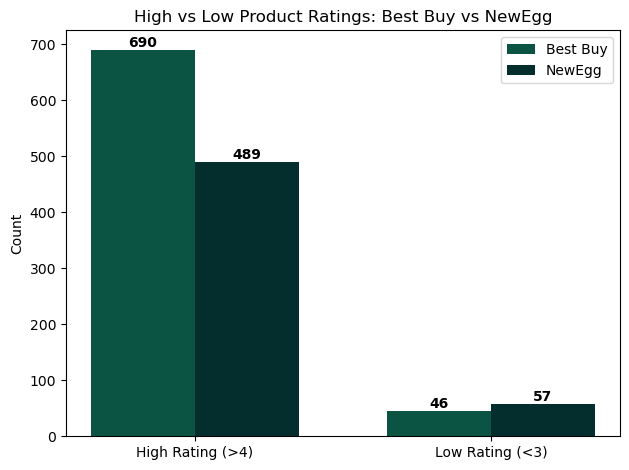

In [50]:
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

best_buy_high = best_buy_df[best_buy_df['customerReviewAverage'] >= 4]
best_buy_low = best_buy_df[best_buy_df['customerReviewAverage'] < 3]
new_egg_high = new_egg_df[new_egg_df['customerReviewAverage'] >= 4]
new_egg_low = new_egg_df[new_egg_df['customerReviewAverage'] < 3]


# Counts
best_buy_counts = [len(best_buy_high), len(best_buy_low)]
new_egg_counts  = [len(new_egg_high), len(new_egg_low)]

labels = ['High Rating (>4)', 'Low Rating (<3)']
x = np.arange(len(labels))
width = 0.35

# Custom colors (converted 0–1)
best_buy_color = (11/255, 84/255, 68/255)
new_egg_color  = (4/255, 46/255, 46/255)

fig, ax = plt.subplots()

# Bars
bars1 = ax.bar(x - width/2, best_buy_counts, width, label='Best Buy', color=best_buy_color)
bars2 = ax.bar(x + width/2, new_egg_counts, width, label='NewEgg', color=new_egg_color)

# Add counts on top
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            str(int(bar.get_height())), ha='center', va='bottom', fontweight='bold')

for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            str(int(bar.get_height())), ha='center', va='bottom', fontweight='bold')

ax.set_ylabel('Count')
ax.set_title('High vs Low Product Ratings: Best Buy vs NewEgg')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

plt.tight_layout()
plt.show()




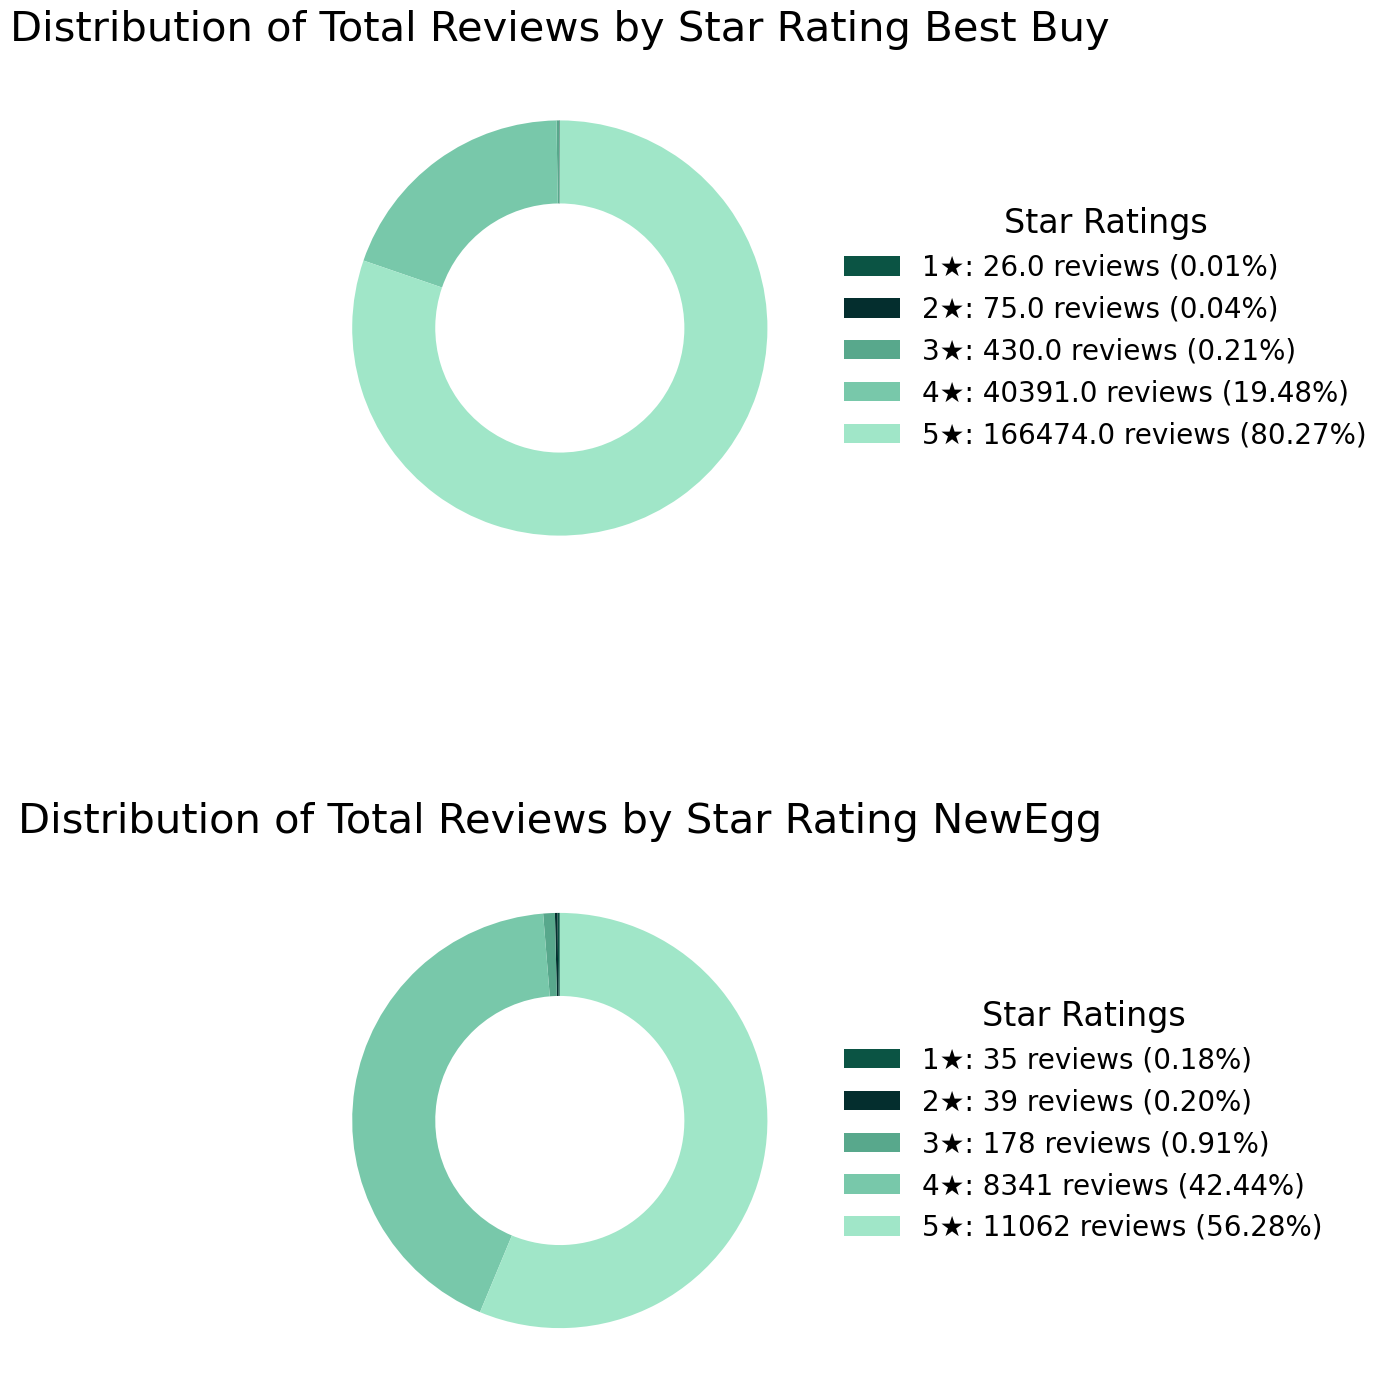

In [49]:
import matplotlib.pyplot as plt

# Updated 5-shade green palette
colors = [
    (11/255, 84/255, 68/255),     
    (4/255, 46/255, 46/255),      
    (88/255, 168/255, 140/255),   
    (120/255, 200/255, 170/255),  
    (160/255, 230/255, 200/255)   
]

def plot_donut(ax, df, title):
    df["ratingRounded"] = df["customerReviewAverage"].round()
    rating_sums = df.groupby("ratingRounded")["customerReviewCount"].sum()
    total = rating_sums.sum()
    
    wedges, _ = ax.pie(
        rating_sums,
        labels=None,
        colors=[colors[i % len(colors)] for i in range(len(rating_sums))],
        startangle=90,
        wedgeprops={'width':0.4}  # donut hole
    )
    
    # Legend with counts and percentages
    legend_labels = [
        f"{int(s)}★: {rating_sums[s]} reviews ({rating_sums[s]/total*100:.2f}%)"
        for s in rating_sums.index
    ]
    ax.legend(
        wedges,
        legend_labels,
        title="Star Ratings",
        loc="center left",
        bbox_to_anchor=(1, 0.5),
        frameon=False,
        fontsize=20,
        title_fontsize=24
    )
    
    # Centered title with padding
    ax.set_title(title, fontsize=30, pad=20)  # pad moves the title away from the chart

# Vertically stacked figure
fig, axes = plt.subplots(2, 1, figsize=(10, 16))

plot_donut(axes[0], best_buy_df, "Distribution of Total Reviews by Star Rating Best Buy")
plot_donut(axes[1], new_egg_df, "Distribution of Total Reviews by Star Rating NewEgg")

plt.tight_layout()
plt.show()


In [46]:
import plotly.graph_objects as go

# Group data
best_buy_reviews = best_buy_df.groupby('customerReviewAverage')['customerReviewCount'].sum().reset_index()
new_egg_reviews = new_egg_df.groupby('customerReviewAverage')['customerReviewCount'].sum().reset_index()

# Define dark and light green for continuous color scale
dark_green = 'rgb(4,46,46)'
light_green = 'rgb(160,230,200)'

# --- Best Buy Bar ---
fig_bb = go.Figure()

fig_bb.add_trace(go.Bar(
    x=best_buy_reviews['customerReviewAverage'],
    y=best_buy_reviews['customerReviewCount'],
    text=best_buy_reviews['customerReviewCount'],
    textposition='outside',
    marker=dict(
        color=best_buy_reviews['customerReviewCount'],
        colorscale=[[0, 'rgb(160,230,200)'],[1, 'rgb(4,46,46)']],
        colorbar=dict(title="Review Count", titlefont=dict(size=16), tickfont=dict(size=14))
    ),
    showlegend=False
))

fig_bb.update_layout(
    title=dict(text="Best Buy Total Review Count per Review Average", x=0.5, font=dict(size=28)),
    xaxis=dict(title="Average Rating", titlefont=dict(size=20),tickfont=dict(size=16), showgrid=True, gridcolor='lightgray'),
    yaxis=dict(title="Total Review Count", titlefont=dict(size=20),tickfont=dict(size=16), showgrid=True, gridcolor='lightgray'),
    plot_bgcolor='white',
    paper_bgcolor='white',
    height=500
)

fig_bb.show()


# --- New Egg Bar ---
fig_ne = go.Figure()

fig_ne.add_trace(go.Bar(
    x=new_egg_reviews['customerReviewAverage'],
    y=new_egg_reviews['customerReviewCount'],
    text=new_egg_reviews['customerReviewCount'],
    textposition='outside',
    marker=dict(
        color=new_egg_reviews['customerReviewCount'],
        colorscale=[[0, 'rgb(160,230,200)'],[1, 'rgb(4,46,46)']],
        colorbar=dict(title="Review Count", titlefont=dict(size=16), tickfont=dict(size=14))
    ),
    showlegend=False
))

fig_ne.update_layout(
    title=dict(text="New Egg Total Review Count per Review Average", x=0.5, font=dict(size=28)),
    xaxis=dict(title="Average Rating", titlefont=dict(size=20), tickfont=dict(size=16), showgrid=True, gridcolor='lightgray'),
    yaxis=dict(title="Total Review Count", titlefont=dict(size=20), tickfont=dict(size=16), showgrid=True, gridcolor='lightgray'),
    plot_bgcolor='white',
    paper_bgcolor='white',
    height=500
)

fig_ne.show()


